In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:

df = pd.read_csv(r"C:\Users\madhu\Downloads\Telegram Desktop\ml project\dataset1.csv")

df.head()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [11]:
df.columns = df.columns.str.strip()

X = df[[
    'having_IPhaving_IP_Address',
    'URLURL_Length',
    'Shortining_Service',
    'having_At_Symbol'
]]

y = df['Result']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Accuracy: 0.9678878335594754
Classification Report:
               precision    recall  f1-score   support

          -1       0.98      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211

Random Forest Accuracy: 0.9678878335594754


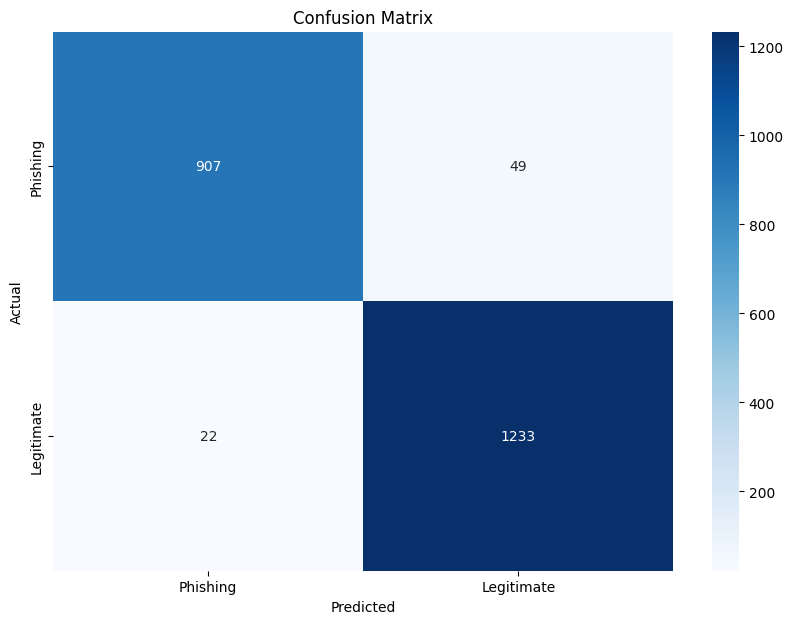

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
rf_acc = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", rf_acc)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Phishing', 'Legitimate'], yticklabels=['Phishing', 'Legitimate'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.9231117141564903
Logistic Regression Classification Report:
               precision    recall  f1-score   support

          -1       0.92      0.90      0.91       956
           1       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211

Logistic Regression Accuracy: 0.9231117141564903


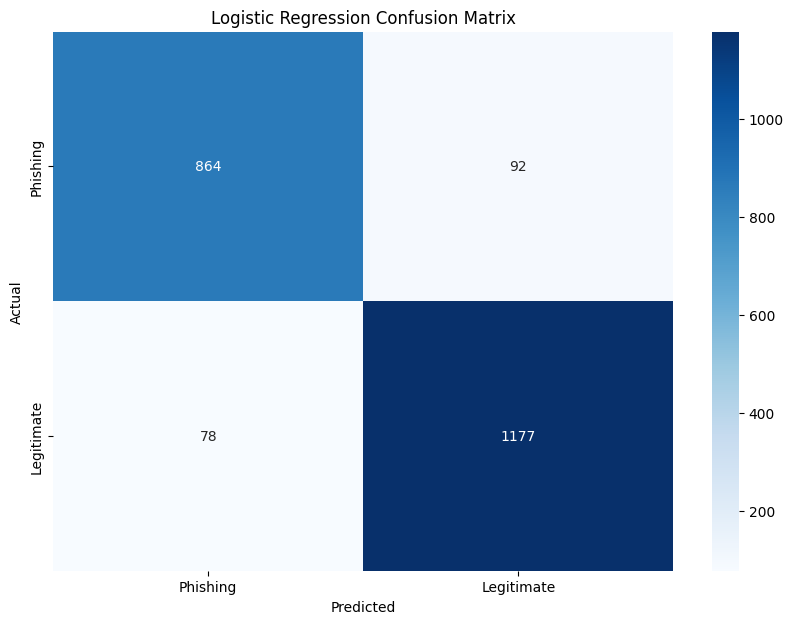

In [9]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_log))
log_acc = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_acc)


# confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=['Phishing', 'Legitimate'], yticklabels=['Phishing', 'Legitimate'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Decision Tree Accuracy: 0.9520578923563998
Decision Tree Classification Report:
               precision    recall  f1-score   support

          -1       0.95      0.94      0.94       956
           1       0.95      0.96      0.96      1255

    accuracy                           0.95      2211
   macro avg       0.95      0.95      0.95      2211
weighted avg       0.95      0.95      0.95      2211

Decision Tree Accuracy: 0.9520578923563998


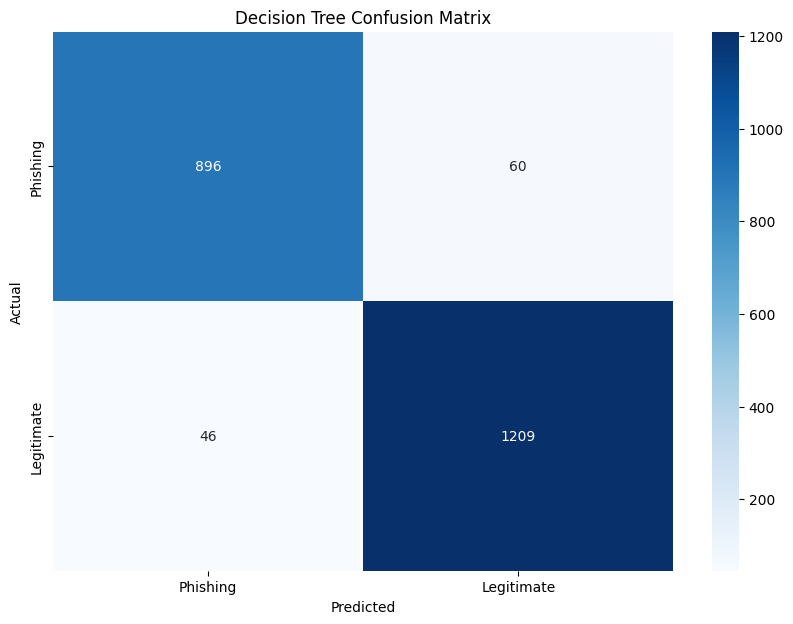

In [10]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
dt_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_acc)

# confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Phishing', 'Legitimate'], yticklabels=['Phishing', 'Legitimate'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [11]:
# Initialize a dictionary to store performance scores
model_scores = {}

model_scores["Random Forest"] = {
    "model_object": rf,
    "accuracy": rf_acc
}

model_scores["logistic Regression"] = {
    "model_object": log_reg,
    "accuracy": log_acc
}

model_scores["Decision Tree"] = {
    "model_object": dt,
    "accuracy": dt_acc
}


In [12]:
# Find the model name with the highest accuracy score
best_model_name = max(model_scores, key=lambda k: model_scores[k]["accuracy"])

# Extract the winning details
best_model_data = model_scores[best_model_name]
best_model_obj = best_model_data["model_object"]
best_model_score = best_model_data["accuracy"]

best_model_percentage = best_model_score * 100

print("--- Selection Results ---")
print(f"🥇 Best Model: {best_model_name}")
print(f"📈 Highest Accuracy: {best_model_score:.4f}")
print(f"📈 Highest Accuracy: {best_model_percentage:.2f}%")

--- Selection Results ---
🥇 Best Model: Random Forest
📈 Highest Accuracy: 0.9679
📈 Highest Accuracy: 96.79%


C:\Users\user\AppData\Local\Temp\ipykernel_10776\2780865860.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


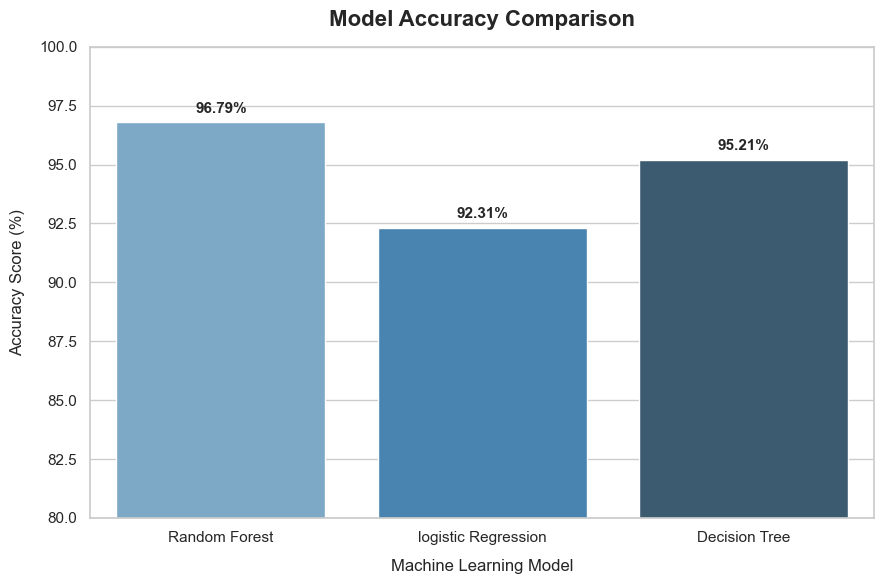

In [13]:
# 1. Convert the scores dictionary to a Pandas DataFrame
data = []
for model_name, info in model_scores.items():
    data.append({
        "Model": model_name,
        "Accuracy (%)": info["accuracy"] * 100  # Convert to percentage
    })

df_results = pd.DataFrame(data)

# 2. Set up the plotting style
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# 3. Create the bar plot
barplot = sns.barplot(
    x="Model", 
    y="Accuracy (%)", 
    data=df_results, 
    palette="Blues_d"
)

# 4. Add the exact percentage values on top of each bar
for bar in barplot.patches:
    height = bar.get_height()
    barplot.annotate(
        f'{height:.2f}%',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),  # 5 points vertical offset
        textcoords="offset points",
        ha='center', 
        va='bottom', 
        fontsize=11, 
        weight='bold'
    )

# 5. Customize titles and labels
plt.title("Model Accuracy Comparison", fontsize=16, pad=15, weight='bold')
plt.xlabel("Machine Learning Model", fontsize=12, labelpad=10)
plt.ylabel("Accuracy Score (%)", fontsize=12, labelpad=10)

# Zoom into the relevant accuracy range (e.g., 80% to 100%) to see variations clearly
plt.ylim(80, 100) 

plt.tight_layout()
plt.show()


In [14]:
import os
import joblib

model_folder = "saved_models"
if not os.path.exists(model_folder):
    os.makedirs(model_folder)
    print(f"Created directory: '{model_folder}'")

for model_name, info in model_scores.items():
    clean_filename = f"{model_name.lower().replace(' ', '_')}.joblib"
    
    save_path = os.path.join(model_folder, clean_filename)
    
    joblib.dump(info["model_object"], save_path)
    print(f"Saved: {model_name} -> {save_path}")


Created directory: 'saved_models'
Saved: Random Forest -> saved_models\random_forest.joblib
Saved: logistic Regression -> saved_models\logistic_regression.joblib
Saved: Decision Tree -> saved_models\decision_tree.joblib


In [15]:
import os
import joblib

# Target the folder inside your current working directory
model_folder = "saved_models"
if not os.path.exists(model_folder):
    os.makedirs(model_folder)

save_path = os.path.join(model_folder, "random_forest.joblib")
joblib.dump(rf, save_path)

save_path = os.path.join(model_folder, "logistic_regression.joblib")
joblib.dump(log_reg, save_path)

save_path = os.path.join(model_folder, "decision_tree.joblib")
joblib.dump(dt, save_path)

print(f"✅ Success! Model saved to: {save_path}")


✅ Success! Model saved to: saved_models\decision_tree.joblib
